1.超参数配置

In [1]:
import json
import os
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# 数据配置
POETRY_FILES = [
    "poet.song.40000.json",
    "poet.song.41000.json",
    "poet.song.42000.json",
    "poet.song.43000.json"
    
]
TARGET_FORMAT = "qijue"  
MAX_VOCAB_SIZE = 10000  

# 模型配置（稍微增大维度）
EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 2
DROPOUT = 0.3

# 训练配置
BATCH_SIZE = 32    # 数据少时减小batch
EPOCHS = 80        # 增加训练轮数
LEARNING_RATE = 0.001
GRAD_CLIP = 5.0    # 梯度裁剪
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
START_WORDS = "明月"
TEMPERATURE = 0.8  # 生成温度



2.数据解析、过滤与数据集加载函数
    parse_and_filter_poetry：单首诗词解析函数，根据七言绝句规则，统一替换标点为分隔符、分句，严格校验句数 + 每句汉字数量，过滤不合格杂诗、残诗，只保留纯标准汉字诗词序列；
    load_poetry_data：批量遍历指定 JSON 文件，判断文件是否存在、逐首读

In [2]:

def parse_and_filter_poetry(poem_content, target_format):
    if target_format == "qijue":
        char_per_sentence = 7
        num_sentences = 4
    elif target_format == "wujue":
        char_per_sentence = 5
        num_sentences = 4
    else:
        return None

    text = poem_content.replace("，", "|").replace("。", "|")
    text = text.replace("！", "|").replace("？", "|").replace("；", "|")
    
    sentences = [s.strip() for s in text.split("|") if s.strip()]
    
    if len(sentences) != num_sentences:
        return None
    for sent in sentences:
        clean_sent = re.sub(r"[^\u4e00-\u9fa5]", "", sent)
        if len(clean_sent) != char_per_sentence:
            return None
    
    full_poem = "".join([re.sub(r"[^\u4e00-\u9fa5]", "", s) for s in sentences])
    return full_poem

def load_poetry_data(files, target_format):
    poetry_list = []
    for file in files:
        if not os.path.exists(file):
            print(f"文件 {file} 不存在，已跳过")
            continue
        print(f"正在加载 {file} ...")
        with open(file, "r", encoding="utf-8") as f:
            raw_data = json.load(f)
            for poem in raw_data:
                raw_text = "".join(poem["paragraphs"])
                parsed_poem = parse_and_filter_poetry(raw_text, target_format)
                if parsed_poem:
                    poetry_list.append(parsed_poem)
    
    print(f"\n数据加载完成！共找到符合{target_format}格式的古诗 {len(poetry_list)} 首")
    return poetry_list

3.构建字级词汇表
    神经网络无法直接识别汉字，必须映射为数字索引
    遍历所有合规古诗，统计每个汉字出现频次；
    按字频从高到低排序，截取指定最大词汇表容量的高频汉字；
    加入特殊占位符 <PAD> 填充符、<UNK> 未知生僻字符；
    构建 word2idx 汉字转索引、idx2word 索引转回汉字双向字典，供模型训练和诗词生成时互转使用。

In [3]:
def build_vocab(poetry_list, max_vocab_size):
    char_count = {}
    for poem in poetry_list:
        for char in poem:
            char_count[char] = char_count.get(char, 0) + 1
    
    sorted_chars = sorted(char_count.items(), key=lambda x: x[1], reverse=True)[:max_vocab_size]
    special_tokens = ["<PAD>", "<UNK>"]
    vocab = special_tokens + [char for char, _ in sorted_chars]
    
    word2idx = {char: idx for idx, char in enumerate(vocab)}
    idx2word = {idx: char for idx, char in enumerate(vocab)}
    print(f"词汇表大小：{len(vocab)}")
    return word2idx, idx2word, len(vocab)

4.自定义数据集类 + LSTM 网络模型类
    PoetryDataset 自定义数据集：
    将每首古诗汉字序列转为数字索引序列；
    划分输入序列和目标序列（用前 n 个字预测下一个字）；
    适配 PyTorch DataLoader 规范，实现批量迭代取数据。
    PoetryLSTM LSTM 神经网络模型：
    嵌入层：将数字索引转为稠密词嵌入向量；
    多层 LSTM：学习诗词上下文时序依赖、平仄押韵规律；
    Dropout 层：抑制过拟合；
    全连接层：输出对应词汇表每个字的预测概率；
    前向传播函数：支持自定义隐态初始化，适配训练与生成两种场景。

In [4]:
class PoetryDataset(Dataset):
    def __init__(self, poetry_list, word2idx):
        self.word2idx = word2idx
        self.idx_sequences = []
        for poem in poetry_list:
            seq = [word2idx.get(char, word2idx["<UNK>"]) for char in poem]
            self.idx_sequences.append(seq)

    def __len__(self):
        return len(self.idx_sequences)

    def __getitem__(self, idx):
        seq = self.idx_sequences[idx]
        input_seq = torch.tensor(seq[:-1], dtype=torch.long)
        target_seq = torch.tensor(seq[1:], dtype=torch.long)
        return input_seq, target_seq

class PoetryLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers, dropout=0.3):
        super(PoetryLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        batch_size = x.size(0)
        embed_x = self.embedding(x)
        
        if hidden is None:
            h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
            hidden = (h0, c0)
        
        lstm_out, hidden = self.lstm(embed_x, hidden)
        out = self.dropout(lstm_out)
        out = self.fc(out)
        return out, hidden

5.温度采样诗词生成函数
    采用温度采样机制，通过温度系数缩放预测概率分布；
    以自定义开头字为起始，逐字迭代预测下一个汉字，拼接成完整诗词；
    按七言28字、五言20字规则自动换行排版，输出标准绝句格式；
    推理时关闭模型梯度计算、切换评估模式，提升生成速度且防止权重更新。

In [5]:
def generate_with_temperature(model, start_words, word2idx, idx2word, seq_length, device, temperature=0.8):
    model.eval()
    input_seq = [word2idx.get(char, word2idx["<UNK>"]) for char in start_words]
    input_tensor = torch.tensor(input_seq, dtype=torch.long).unsqueeze(0).to(device)

    hidden = None
    with torch.no_grad():
        _, hidden = model(input_tensor, hidden)

    current_char = input_seq[-1]
    full_poetry = start_words
    need_generate_num = seq_length - len(start_words)

    for _ in range(need_generate_num):
        current_tensor = torch.tensor([[current_char]], dtype=torch.long).to(device)
        with torch.no_grad():
            output, hidden = model(current_tensor, hidden)
            
            # 温度采样
            logits = output.squeeze() / temperature
            # 计算概率分布
            probs = torch.softmax(logits, dim=-1)
            # 按概率采样
            next_char_idx = torch.multinomial(probs, num_samples=1).item()
            
            next_char = idx2word.get(next_char_idx, "<UNK>")
            full_poetry += next_char
            current_char = next_char_idx

    # 按格式分行
    if seq_length == 28:
        formatted = "\n".join([full_poetry[i*7:(i+1)*7] for i in range(4)])
    elif seq_length == 20:
        formatted = "\n".join([full_poetry[i*5:(i+1)*5] for i in range(4)])
    else:
        formatted = full_poetry

    model.train()
    return formatted



6.训练
    根据绝句类型自动设定诗词固定长度；
    调用数据加载、词表构建，初始化数据集与批量加载器；
    初始化 LSTM 模型、交叉熵损失函数、Adam 优化器、学习率衰减调度器；
    迭代多轮训练：前向传播计算损失、反向传播更新权重、梯度裁剪防止爆炸、学习率自动衰减；
    每训练 5 轮自动调用生成函数，实时输出作诗效果，观察模型收敛进度；
    训练结束绘制 Loss 变化曲线，直观查看收敛情况；

正在加载 poet.song.40000.json ...
正在加载 poet.song.41000.json ...
正在加载 poet.song.42000.json ...
正在加载 poet.song.43000.json ...

数据加载完成！共找到符合qijue格式的古诗 901 首
词汇表大小：2823

Epoch [1/80] Average Loss: 7.3694

Epoch [2/80] Average Loss: 7.0118

Epoch [3/80] Average Loss: 6.9617

Epoch [4/80] Average Loss: 6.9248

Epoch [5/80] Average Loss: 6.8629
【生成演示】:
明月羞黄松有江
名城行只作絲要
夜中便煮知朝方
步暮伴使名卵暮

Epoch [6/80] Average Loss: 6.7622

Epoch [7/80] Average Loss: 6.5982

Epoch [8/80] Average Loss: 6.3748

Epoch [9/80] Average Loss: 6.0989

Epoch [10/80] Average Loss: 5.7955
【生成演示】:
明月未罩李嵐倚
景秋雲客天相蝶
衛說似雲春綠湖
年外一杯櫂華懷

Epoch [11/80] Average Loss: 5.4640

Epoch [12/80] Average Loss: 5.1242

Epoch [13/80] Average Loss: 4.7739

Epoch [14/80] Average Loss: 4.4164

Epoch [15/80] Average Loss: 4.0647
【生成演示】:
明月華田見在落
山落青花不枝沉
離與人間趁更來
將上傍人舊分春

Epoch [16/80] Average Loss: 3.7288

Epoch [17/80] Average Loss: 3.3947

Epoch [18/80] Average Loss: 3.0721

Epoch [19/80] Average Loss: 2.7701

Epoch [20/80] Average Loss: 2.4726
【生成演示】:


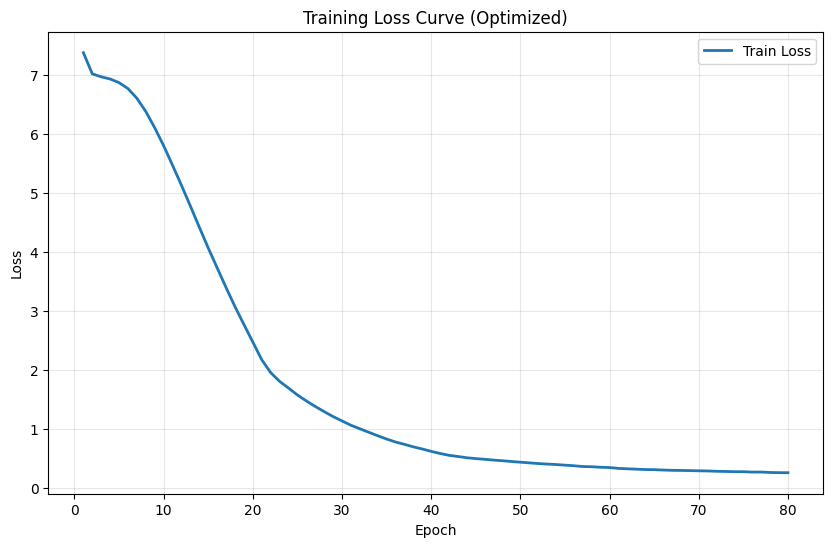

In [6]:
def main():
    # 加载数据
    if TARGET_FORMAT == "qijue":
        SEQ_LEN = 28
    else:
        SEQ_LEN = 20
        
    poetry_list = load_poetry_data(POETRY_FILES, TARGET_FORMAT)
    if len(poetry_list) == 0:
        print("错误：未加载到任何古诗，请检查数据集文件")
        return

    # 构建词汇表
    word2idx, idx2word, vocab_size = build_vocab(poetry_list, MAX_VOCAB_SIZE)

    # 构建DataLoader
    dataset = PoetryDataset(poetry_list, word2idx)
    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=True
    )

    # 初始化模型
    model = PoetryLSTM(
        vocab_size=vocab_size,
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    # 学习率衰减：每20轮衰减为原来的0.5
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

    # 5. 训练循环
    model.train()
    loss_history = []

    for epoch in range(EPOCHS):
        total_loss = 0
        step_total = 0

        for step, (input_seq, target_seq) in enumerate(dataloader):
            input_seq = input_seq.to(DEVICE)
            target_seq = target_seq.to(DEVICE)

            output, _ = model(input_seq)
            loss = criterion(output.reshape(-1, vocab_size), target_seq.reshape(-1))

            optimizer.zero_grad()
            loss.backward()
            # 梯度裁剪
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            total_loss += loss.item()
            step_total += 1

        # 更新学习率
        scheduler.step()
        
        # 记录并打印
        epoch_avg_loss = total_loss / step_total
        loss_history.append(epoch_avg_loss)
        print(f"\nEpoch [{epoch+1}/{EPOCHS}] Average Loss: {epoch_avg_loss:.4f}")
        
        # 每5轮生成一次演示
        if (epoch + 1) % 5 == 0:
            print("【生成演示】:")
            poem = generate_with_temperature(
                model, START_WORDS, word2idx, idx2word, SEQ_LEN, DEVICE, TEMPERATURE
            )
            print(poem)

    # 6. 绘制Loss曲线
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, EPOCHS+1), loss_history, label="Train Loss", color="#1f77b4", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss Curve (Optimized)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig("loss_curve_optimized.png", dpi=300)
    plt.show()

    # 7. 保存模型
    torch.save({
        "model_state_dict": model.state_dict(),
        "word2idx": word2idx,
        "idx2word": idx2word
    }, "poetry_model_optimized.pth")

if __name__ == "__main__":
    main()